### Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)


### Load Real NFL Game Data

In [42]:
url = 'https://raw.githubusercontent.com/nflverse/nfldata/master/data/games.csv'
data = pd.read_csv(url)
data.sample(5)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7548 entries, 0 to 7547
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7548 non-null   object 
 1   season            7548 non-null   int64  
 2   game_type         7548 non-null   object 
 3   week              7548 non-null   int64  
 4   gameday           7548 non-null   object 
 5   weekday           7548 non-null   object 
 6   gametime          7289 non-null   object 
 7   away_team         7548 non-null   object 
 8   away_score        7276 non-null   float64
 9   home_team         7548 non-null   object 
 10  home_score        7276 non-null   float64
 11  location          7548 non-null   object 
 12  result            7276 non-null   float64
 13  total             7276 non-null   float64
 14  overtime          7276 non-null   float64
 15  old_game_id       7548 non-null   int64  
 16  gsis              7276 non-null   float64


### Filter to Completed Regular-Season Games

### Keep only regular season games

In [43]:
data = data[data['game_type'] == 'REG']

### Drop games that have not been played yet 

In [44]:
data = data.dropna(subset=['home_score', 'away_score'])

## Remove ties and create the target variable

### Drop the small number of small games

In [45]:
data = data[data['home_score'] != data['away_score']]

### Create the target: 1 = home team won, 0 = home team lost

In [46]:
data['home_win'] = (data['home_score'] > data['away_score']).astype(int)

data['home_win'].value_counts()

home_win
1    3905
0    3047
Name: count, dtype: int64

## Clean messy values before modeling

### fill missing weather (most domes have no outdoor weather

In [47]:
data['temp'] = data['temp'].fillna(data['temp'].median())
data['wind'] = data['wind'].fillna(0)

### strip hidden whitespaces "grass" and "grass " aren't treated as two different categories

In [48]:
data['surface'] = data['surface'].str.strip()
data['surface'] = data['surface'].fillna(data['surface'].mode()[0])

### Select Features, focus on thing known before kickoff, not before. 

In [49]:
features_cols = ['spread_line', 'total_line', 'div_game', 'home_rest', 'away_rest', 
                 'temp', 'wind', 'roof', 'surface']
model_data = data[features_cols + ['home_win']].copy()

In [50]:
model_data = pd.get_dummies(model_data, columns=['roof', 'surface'], drop_first=True)

X = model_data.drop(columns=['home_win']) # feature
y = model_data['home_win'] # target

## Train, Test, Split (with stratification)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Scale the numeric feature

In [52]:
numeric_cols = ['spread_line', 'total_line', 'home_rest', 'away_rest', 'temp', 'wind']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Train a Logistic Regression Model

In [53]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluate with Accuracy and a Classification Report

In [54]:
y_pred = model.predict(X_test)
y_proba =model.predict_proba(X_test)[:, 1] #probility of a home win

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6455787203450755
              precision    recall  f1-score   support

           0       0.62      0.51      0.56       610
           1       0.66      0.75      0.70       781

    accuracy                           0.65      1391
   macro avg       0.64      0.63      0.63      1391
weighted avg       0.64      0.65      0.64      1391



### Visualize the Confusion Matrix

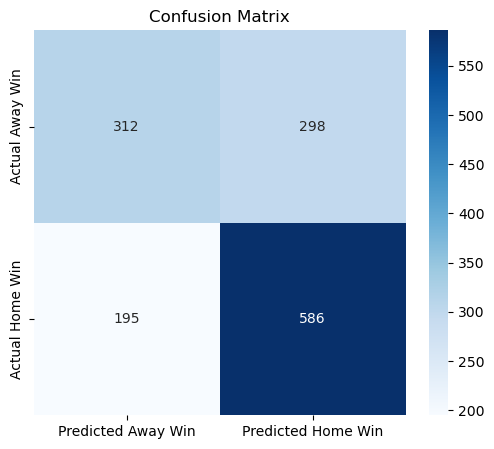

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Away Win', 'Predicted Home Win'],
            yticklabels=['Actual Away Win', 'Actual Home Win'])
plt.title('Confusion Matrix')
plt.show()

## Plot the ROC Curve and AUC Score

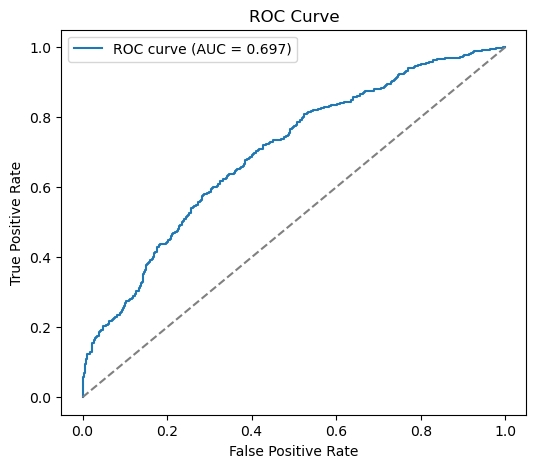

In [58]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') # baseline = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Examine which Features Matter Most

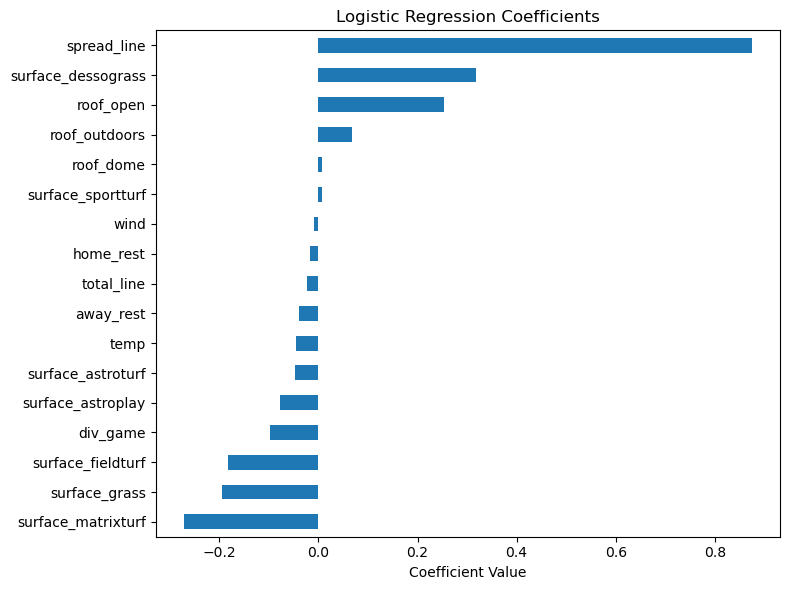

In [60]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## Team Strength Visualization (EPA per play)
Building rbsdm.com-style team tier charts from nflverse play-by-play data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load 2025 play-by-play data straight from nflverse (same source as rbsdm.com charts)

In [ ]:
TEAM_COLORS = {
    'ARI': '#97233F', 'ATL': '#A71930', 'BAL': '#241773', 'BUF': '#00338D',
    'CAR': '#0085CA', 'CHI': '#0B162A', 'CIN': '#FB4F14', 'CLE': '#FF3C00',
    'DAL': '#002244', 'DEN': '#FB4F14', 'DET': '#0076B6', 'GB':  '#203731',
    'HOU': '#03202F', 'IND': '#002C5F', 'JAX': '#006778', 'KC':  '#E31837',
    'LA':  '#003594', 'LAC': '#0080C6', 'LV':  '#000000', 'MIA': '#008E97',
    'MIN': '#4F2683', 'NE':  '#002244', 'NO':  '#D3BC8D', 'NYG': '#0B2265',
    'NYJ': '#125740', 'PHI': '#004C54', 'PIT': '#FFB612', 'SEA': '#002244',
    'SF':  '#AA0000', 'TB':  '#D50A0A', 'TEN': '#0C2340', 'WAS': '#5A1414',
}

# Load 2025 play-by-play data straight from nflverse (same source as rbsdm.com charts)

In [2]:
pbp = pd.read_parquet(
    'https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.parquet',
    columns=['season', 'week', 'season_type', 'posteam', 'defteam',
             'epa', 'play_type', 'pass', 'rush']
)


## Regular season only, real offensive plays (pass or rush) with a valid EPA

In [3]:
plays = pbp[
    (pbp['season_type'] == 'REG') &
    (pbp['epa'].notna()) &
    ((pbp['pass'] == 1) | (pbp['rush'] == 1)) &
    (pbp['posteam'].notna())
].copy()

print(f"{len(plays):,} plays loaded")

34,429 plays loaded


In [4]:
def build_tiers(df):
    """Return a DataFrame with offensive and defensive EPA/play per team."""
    off = df.groupby('posteam')['epa'].mean().rename('off_epa')
    # Defense: EPA allowed per play. Flip the sign so higher = better defense.
    defn = (-df.groupby('defteam')['epa'].mean()).rename('def_epa')
    return pd.concat([off, defn], axis=1).reset_index(names='team')


def plot_tiers(tiers, title, subtitle):
    fig, ax = plt.subplots(figsize=(12, 9))

    lim = max(tiers['off_epa'].abs().max(), tiers['def_epa'].abs().max()) * 1.2
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Diagonal tier bands (total strength = off + def is constant on each line)
    band_vals = np.linspace(-2 * lim, 2 * lim, 17)
    for i in range(len(band_vals) - 1):
        c = band_vals[i]
        # color by total strength: orange = bad, blue = good
        strength = (c + band_vals[i + 1]) / 2
        frac = (strength + 2 * lim) / (4 * lim)          # 0..1
        color = plt.cm.RdYlBu(0.15 + 0.7 * frac)
        ax.fill_between([-lim, lim],
                        [c - (-lim), c - lim],
                        [band_vals[i + 1] - (-lim), band_vals[i + 1] - lim],
                        color=color, alpha=0.35, zorder=0)
        ax.plot([-lim, lim], [c - (-lim), c - lim],
                color='gray', lw=0.5, alpha=0.5, zorder=1)

    ax.axhline(0, color='black', lw=0.8, zorder=2)
    ax.axvline(0, color='black', lw=0.8, zorder=2)

    for _, row in tiers.iterrows():
        ax.text(row['off_epa'], row['def_epa'], row['team'],
                ha='center', va='center', fontsize=13, fontweight='bold',
                color=TEAM_COLORS.get(row['team'], 'black'), zorder=3)

    ax.set_xlabel('Offensive strength (EPA per play)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Defensive strength (EPA per play allowed, flipped)',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'{title}\n', fontsize=18, fontweight='bold', loc='left')
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=11, color='dimgray')
    ax.text(1, -0.09, 'Data: nflverse play-by-play  |  Chart: Javice Chisholm',
            transform=ax.transAxes, fontsize=8, color='gray', ha='right')

    plt.tight_layout()
    plt.show()

In [8]:
season = int(plays['season'].iloc[0])
sub = f'{season} NFL regular season, EPA per play (offense vs defense)'

### 1. Overall team tiers

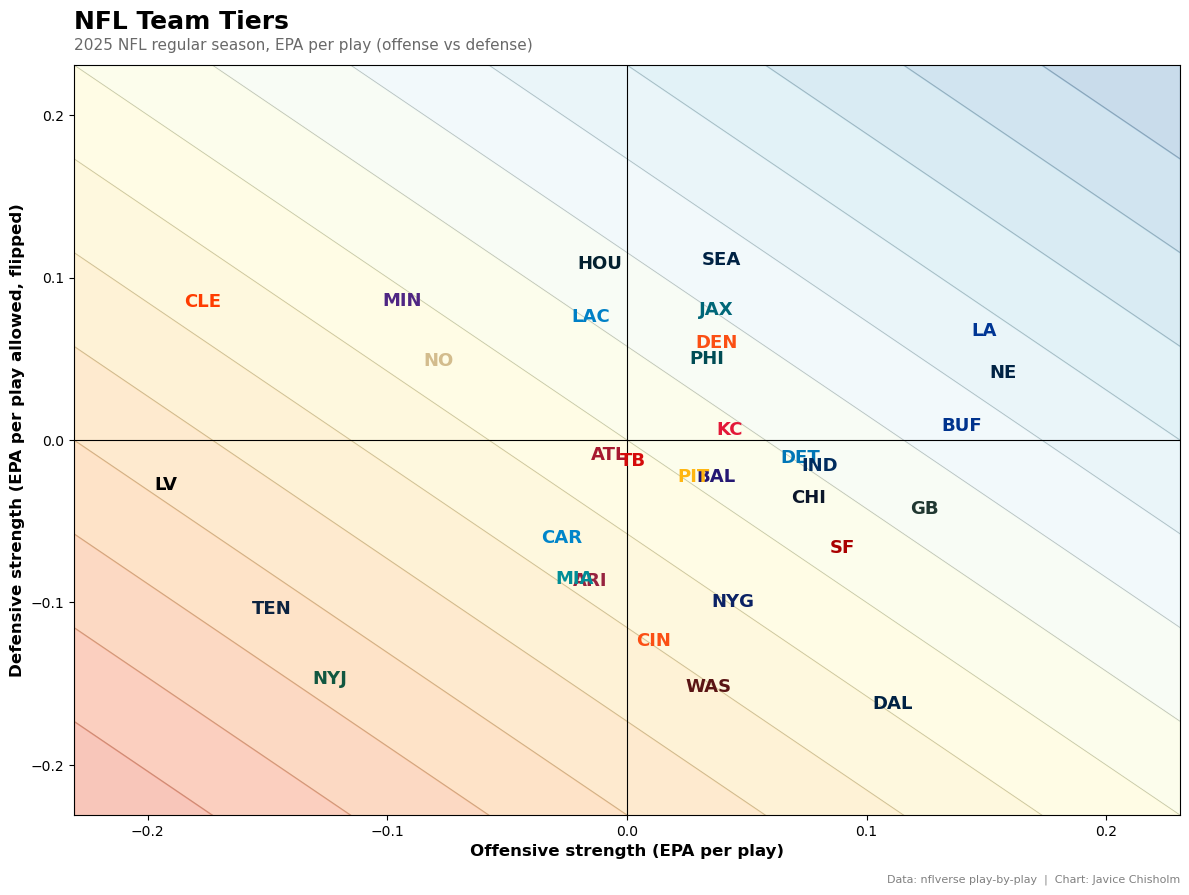

In [9]:
plot_tiers(build_tiers(plays), 'NFL Team Tiers', sub)

### 2. Rushing only

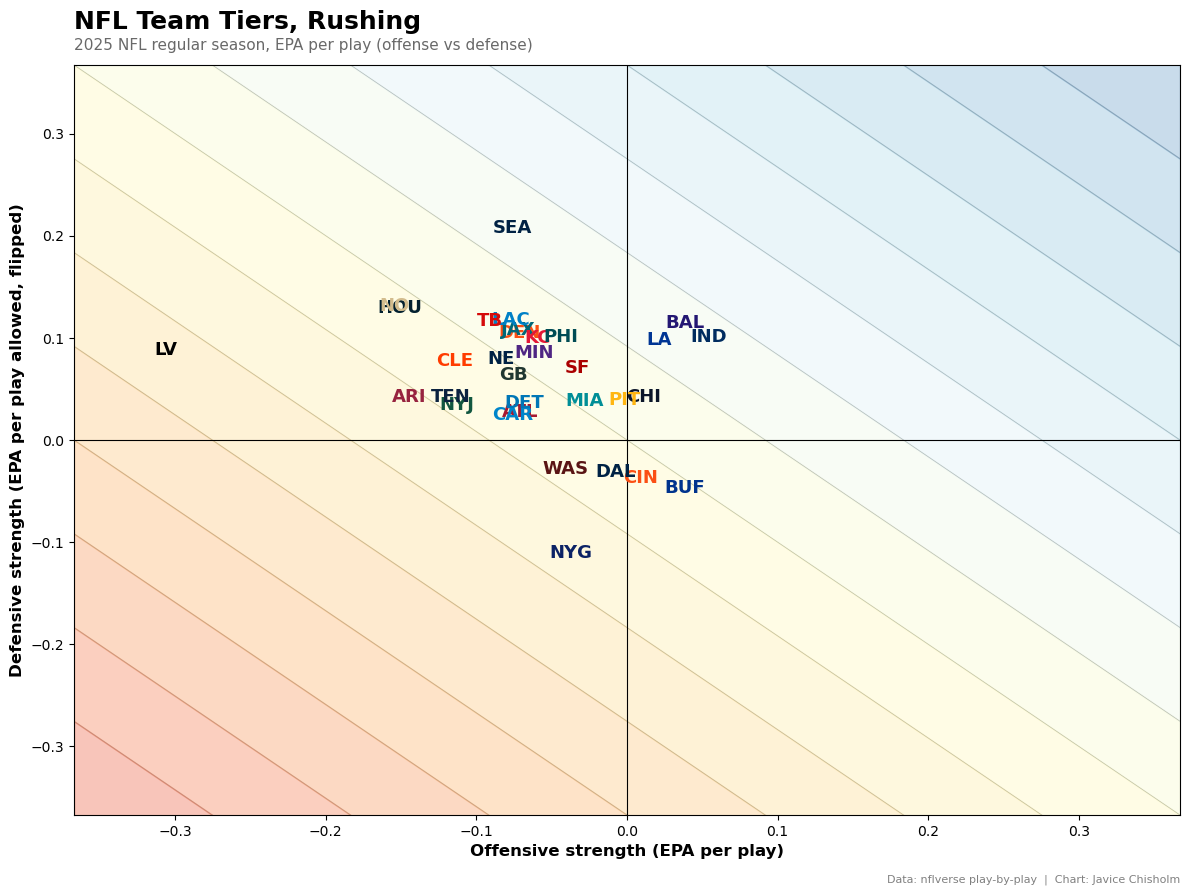

In [11]:
plot_tiers(build_tiers(plays[plays['rush'] == 1]), 'NFL Team Tiers, Rushing', sub)

In [ ]:
### 3. Passing only

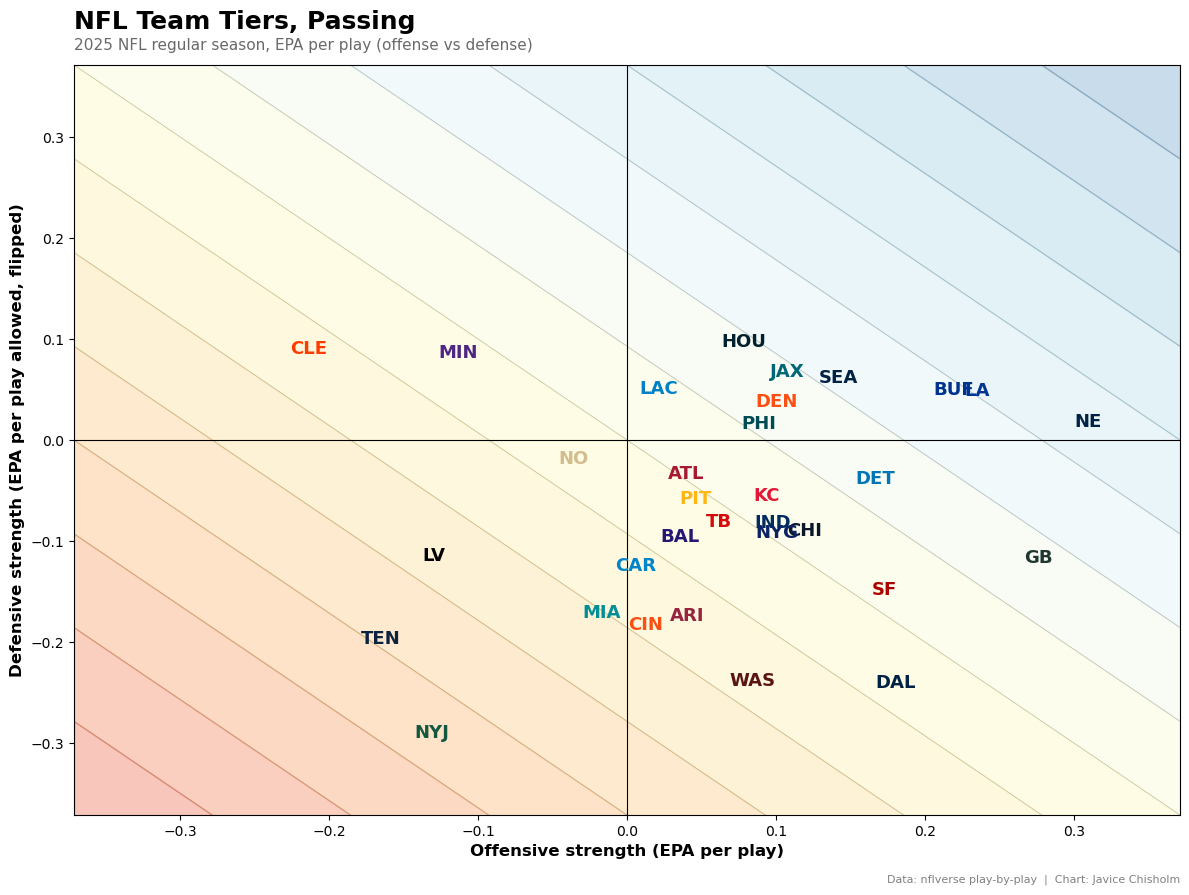

In [12]:
plot_tiers(build_tiers(plays[plays['pass'] == 1]), 'NFL Team Tiers, Passing', sub)

### Team strength table: total = offense + defense

In [7]:
tiers = build_tiers(plays)
tiers['total'] = tiers['off_epa'] + tiers['def_epa']
tiers.sort_values('total', ascending=False).round(3).reset_index(drop=True)

,team,off_epa,def_epa,total
0,LA,0.149,0.067,0.216
1,NE,0.157,0.041,0.198
2,SEA,0.039,0.111,0.151
3,BUF,0.140,0.008,0.148
4,JAX,0.037,0.080,0.117
5,DEN,0.037,0.060,0.097
6,HOU,-0.012,0.109,0.097
7,PHI,0.033,0.050,0.083
8,GB,0.124,-0.043,0.082
9,IND,0.080,-0.016,0.064
